In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys


df = pd.read_csv('https://raw.githubusercontent.com/kimurasaika/car_price_prediction/refs/heads/main/data2.csv')
df = df.drop(columns=['obs','month','month_num','year','PPI_IDX','GOLD'])

df['M2'] = df['M2'].str.replace(',', '').astype(float)

X = df.drop(columns=['CPI_IDX'])

# from sklearn.preprocessing import QuantileTransformer
# quantile = QuantileTransformer(output_distribution='normal', n_quantiles=20 , random_state=8)
# df['CPI_IDX'] = quantile.fit_transform(df['CPI_IDX'].values.reshape(-1, 1))
y = df['CPI_IDX']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=8)
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
imputer = IterativeImputer(max_iter=10, random_state=1234)
imputer.fit(X_train)
X_train = pd.DataFrame(imputer.transform(X_train), columns=X_train.columns)

mylist = ['EX_AVG_USD', 'IMI_IDX', 'policy', 'oilwtiprice']

X_train = X_train[mylist]
X_test = X_test[mylist]

In [ ]:
y_train_log = np.array(y_train)
y_test_log = np.array(y_test)

In [ ]:
# @title
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import matplotlib.pyplot as plt
import pylab
from scipy import stats

def stepwise_selection(X, y, threshold_in=0.05, threshold_out=0.05, verbose=True):

    included = []  # เริ่มจากโมเดลว่าง
    excluded = list(X.columns)  # ตัวแปรทั้งหมดที่ยังไม่ได้เลือก

    while True:
        changed = False

        # Forward Selection: ลองเพิ่มตัวแปรที่เหลือทีละตัว
        new_pval = pd.Series(index=excluded, dtype=float)
        for new_feature in excluded:
            model = sm.OLS(y, sm.add_constant(X[included + [new_feature]])).fit()
            new_pval[new_feature] = model.pvalues[new_feature]

        best_pval = new_pval.min()
        if best_pval < threshold_in:  # ถ้ามีตัวแปรที่ p-value < threshold_in
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            excluded.remove(best_feature)
            changed = True
            if verbose:
                print(f'Add {best_feature} with p-value {best_pval:.6f}')

        # Backward Elimination: ตรวจสอบตัวแปรที่อยู่ในโมเดล
        if included:
            model = sm.OLS(y, sm.add_constant(X[included])).fit()
            pvalues = model.pvalues.iloc[1:]  # Exclude constant
            worst_pval = pvalues.max()
            if worst_pval > threshold_out:  # ถ้ามีตัวแปรที่ p-value > threshold_out
                worst_feature = pvalues.idxmax()
                included.remove(worst_feature)
                excluded.append(worst_feature)
                changed = True
                if verbose:
                    print(f'Remove {worst_feature} with p-value {worst_pval:.6f}')

        # ถ้าไม่มีอะไรเปลี่ยนแปลง (ไม่เพิ่มหรือลบตัวแปร) ออกจาก loop
        if not changed:
            break

    return included
def backward_elimination(X, y, threshold_out=0.05, verbose=True):
    included = list(X.columns)
    while included:
        model = sm.OLS(y, sm.add_constant(X[included])).fit()
        pvalues = model.pvalues.iloc[1:]  # Exclude constant
        worst_pval = pvalues.max()
        if worst_pval > threshold_out:
            worst_feature = pvalues.idxmax()
            included.remove(worst_feature)
            if verbose:
                print(f'Remove {worst_feature} with p-value {worst_pval:.6f}')
        else:
            break
    return included


def calculate_vif(df, vif_threshold=7):
    df_with_const = sm.add_constant(df)
    vif_df = pd.DataFrame()
    vif_df['Column'] = df.columns
    vif_df['VIF'] = [variance_inflation_factor(df_with_const.values, i + 1) for i in range(df.shape[1])]

    selected_features = vif_df[vif_df['VIF'] < vif_threshold]['Column'].tolist()

    if 'const' in selected_features:
        selected_features.remove('const')

    return vif_df

In [ ]:
# @title
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
scaler.fit(X_train)
X_train_scale = scaler.transform(X_train)
X_test_scale = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scale, columns=X_train.columns)
X_test = pd.DataFrame(X_test_scale, columns=X_test.columns)

In [ ]:
# @title
# from sklearn.preprocessing import PowerTransformer
# boxbox = PowerTransformer(standardize=True)
# y_train_log = boxbox.fit_transform(y_train.values.reshape(-1, 1))
# y_test_log = boxbox.transform(y_test.values.reshape(-1, 1))

In [ ]:
# @title
# import numpy as np
# from scipy.stats.mstats import winsorize

# # winsorized_data = winsorize(y_train, limits=[0.05, 0.05])  # cap 5% ล่างและบน
# winsorized_data = pd.DataFrame(data = winsorize(y_train, limits=[0.05, 0.05]))
# winsorized_data.describe()

In [ ]:
from sklearn.preprocessing import QuantileTransformer
quantile = QuantileTransformer(output_distribution='normal', n_quantiles=20 , random_state=8)
y_train_log = quantile.fit_transform(y_train.values.reshape(-1, 1))
y_test_log = quantile.transform(y_test.values.reshape(-1, 1))
# print(y_train)


In [ ]:
# @title
# from sklearn.preprocessing import StandardScaler , RobustScaler

# scaler = RobustScaler()
# y_train_log = scaler.fit_transform(y_train_log)
# y_test_log = scaler.fit_transform(y_test_log)


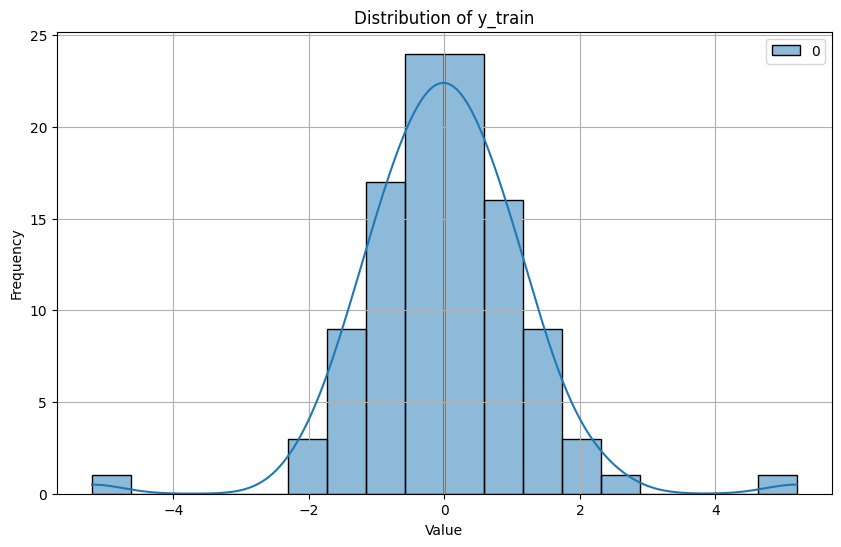

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(y_train_log, kde=True)
plt.title('Distribution of y_train')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


After using quantile transformation

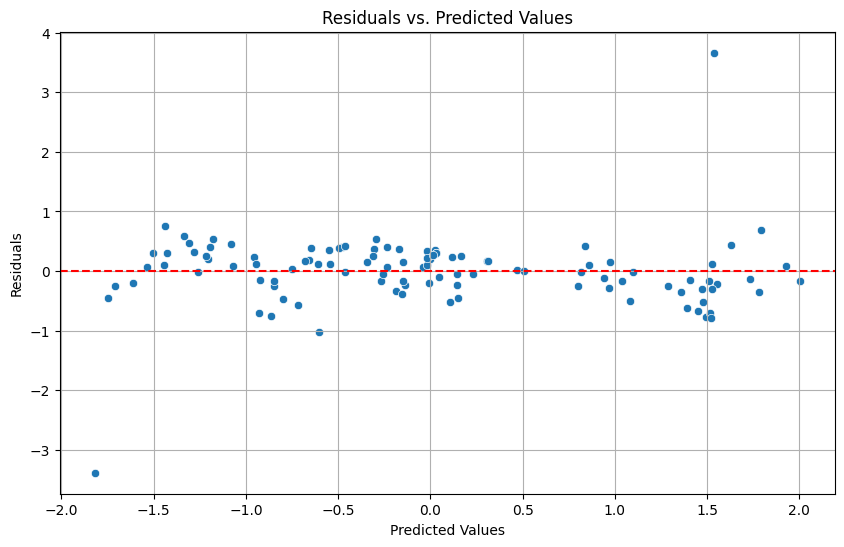

RunTest
Z-test statistic: -2.0811495068651653
P-value: 0.03742022359509915
Durbin-Watson Statistic: 2.10
{'Lagrange multiplier statistic': np.float64(7.381742063470113), 'p-value': np.float64(0.11703845236709523), 'f-value': np.float64(1.8891189534831545), 'f p-value': np.float64(0.11794231785186722)}
Shapiro-Wilk Test: ShapiroResult(statistic=np.float64(0.7180895625496626), pvalue=np.float64(4.184506989579112e-13))
White Test: (np.float64(22.789600147357596), np.float64(0.06378061593279923), np.float64(1.776638278702292), np.float64(0.05382070267701908))
Kolmogorov: KstestResult(statistic=np.float64(0.264059671158982), pvalue=np.float64(3.896804696200352e-07), statistic_location=np.float64(0.46877502512514824), statistic_sign=np.int8(1))


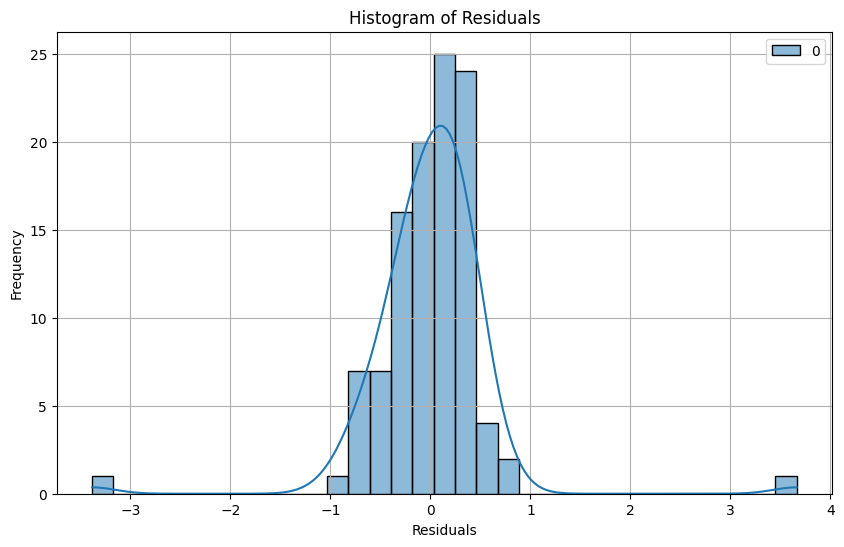

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.743
Model:                            OLS   Adj. R-squared:                  0.733
Method:                 Least Squares   F-statistic:                     74.42
Date:                Mon, 20 Oct 2025   Prob (F-statistic):           1.62e-29
Time:                        07:08:58   Log-Likelihood:                -97.542
No. Observations:                 108   AIC:                             205.1
Df Residuals:                     103   BIC:                             218.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.3006      0.069     -4.357      

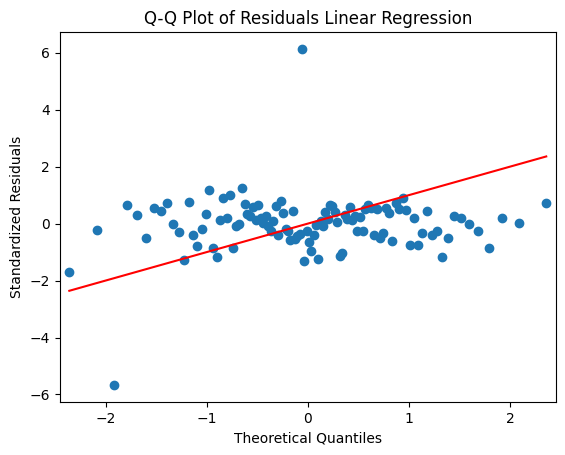

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from statsmodels.sandbox.stats.runs import runstest_1samp

linear_model = LinearRegression().fit(X_train, y_train_log)
y_predlinear = linear_model.predict(X_train)
residualslinear = y_train_log - y_predlinear
y_pred = linear_model.predict(X_test)
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.diagnostic import het_white
from scipy.stats import kstest

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_predlinear.flatten(), y=residualslinear.flatten())
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

z_stat, p_value = runstest_1samp(residualslinear.flatten(), correction=False)
print('RunTest')
print("Z-test statistic:", z_stat)
print("P-value:", p_value)

dw = durbin_watson(residualslinear.flatten())
print(f'Durbin-Watson Statistic: {dw:.2f}')

X_const = sm.add_constant(X_train)
bp_test = het_breuschpagan(residualslinear.flatten(), X_const)
labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
print(dict(zip(labels, bp_test)))

shapiro = stats.shapiro(residualslinear.flatten())
print(f'Shapiro-Wilk Test: {shapiro}')

white_test = het_white(residualslinear.flatten(), X_const)
print(f'White Test: {white_test}')

ks_test = kstest(residualslinear.flatten(), 'norm')
print(f'Kolmogorov: {ks_test}')

plt.figure(figsize=(10, 6))
sns.histplot(residualslinear, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

model_sm = sm.OLS(y_train_log, X_const).fit()
print(model_sm.summary())

sm.qqplot(residualslinear, line='s', fit=True)
plt.title('Q-Q Plot of Residuals Linear Regression')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Standardized Residuals')
plt.show()

In [ ]:
vif = calculate_vif(X_train)
print(vif)

        Column       VIF
0   EX_AVG_USD  1.296229
1      IMI_IDX  3.690903
2       policy  1.250991
3  oilwtiprice  3.727261


In [ ]:
import numpy as np
from scipy import stats

# สมมติ transformed_data คือ array หลัง QuantileTransformer
z_scores = np.abs(stats.zscore(y_train_log))
outliers = np.where(z_scores > 3)  # หา index ของ outliers (z > 3)
print("Outliers indices:", outliers)
clean_data = np.delete(y_train_log, outliers[0])  # ลบ rows ที่มี outliers
y_train_log = clean_data
X_train = X_train.drop(outliers[0]).reset_index(drop=True) # Remove corresponding rows from X_train and reset index
y_train = y_train.drop(outliers[0]).reset_index(drop=True)

Outliers indices: (array([ 2, 51]), array([0, 0]))


In [ ]:
# @title
# from sklearn.preprocessing import PowerTransformer

# pt = PowerTransformer(method='yeo-johnson', standardize=False)
# y_train_log = pt.fit_transform(y_train_log)
# y_test_log = pt.fit_transform(y_test_log)

In [ ]:
# plt.figure(figsize=(10, 6))
# sns.histplot(y_test_log, kde=True)
# plt.title('Distribution of y_train')
# plt.xlabel('Value')
# plt.ylabel('Frequency')
# plt.grid(True)
# plt.show()


Model Linear - RF - SVR


In [ ]:
# @title
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression().fit(X_train, y_train_log)
y_predlinear = linear_model.predict(X_train)
residualslinear = y_train_log - y_predlinear
y_pred = linear_model.predict(X_test)

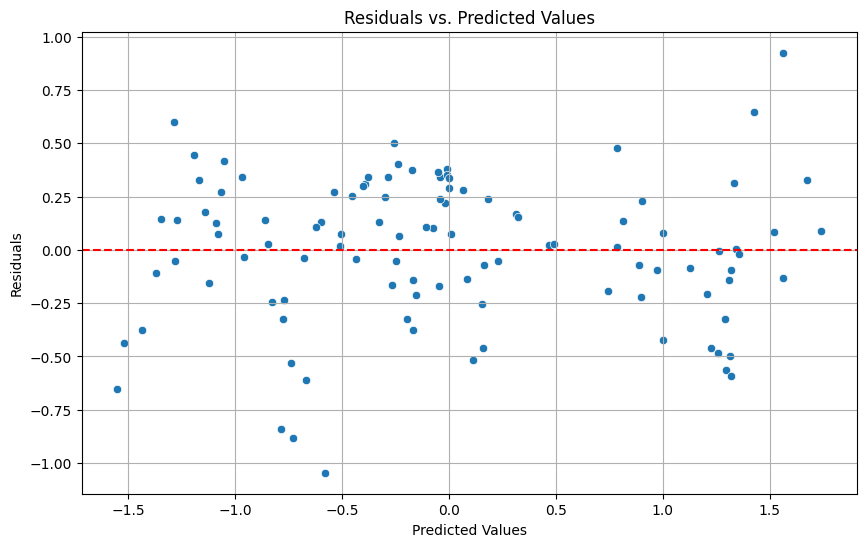

RunTest
Z-test statistic: -1.0888468632617705
P-value: 0.2762214218179101
Durbin-Watson Statistic: 1.61
{'Lagrange multiplier statistic': np.float64(9.82729862204952), 'p-value': np.float64(0.04343949670280888), 'f-value': np.float64(2.580142666800886), 'f p-value': np.float64(0.041750532248740264)}
Shapiro-Wilk Test: ShapiroResult(statistic=np.float64(0.9782510078315065), pvalue=np.float64(0.07909365256327949))
White Test: (np.float64(31.64867886465818), np.float64(0.004492848619959453), np.float64(2.7668158343254223), np.float64(0.0018591545132649594))
Kolmogorov: KstestResult(statistic=np.float64(0.28220346097836535), pvalue=np.float64(5.827529673757492e-08), statistic_location=np.float64(0.4157205949516185), statistic_sign=np.int8(1))


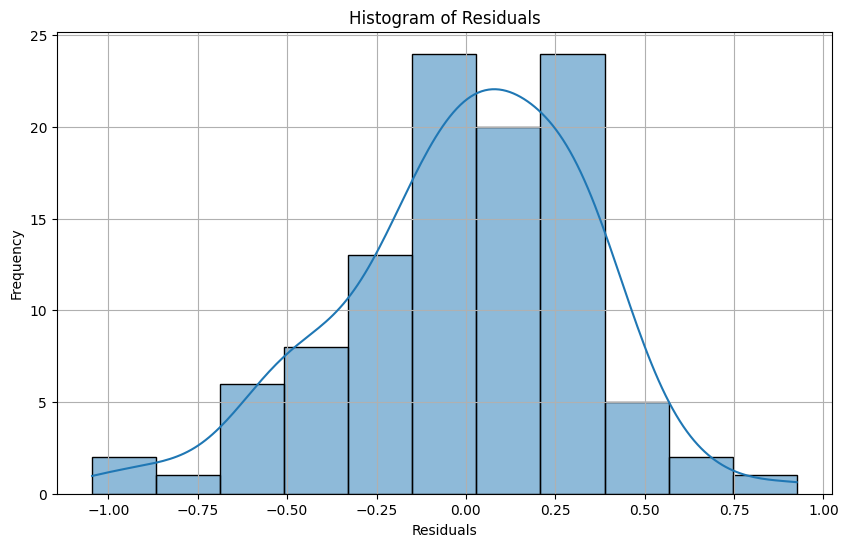

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.872
Model:                            OLS   Adj. R-squared:                  0.867
Method:                 Least Squares   F-statistic:                     172.0
Date:                Mon, 20 Oct 2025   Prob (F-statistic):           3.74e-44
Time:                        07:08:58   Log-Likelihood:                -36.045
No. Observations:                 106   AIC:                             82.09
Df Residuals:                     101   BIC:                             95.41
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.2801      0.040     -7.090      

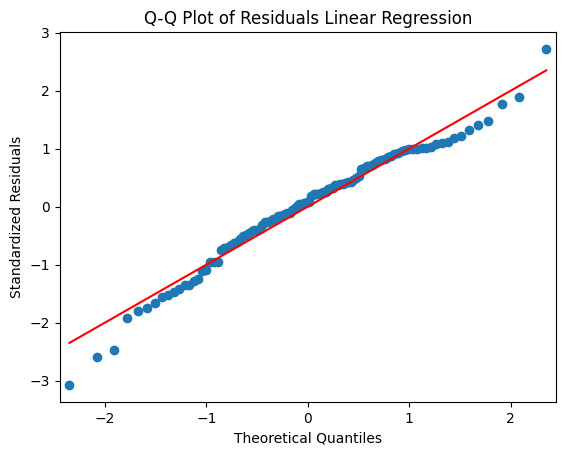

In [ ]:
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.diagnostic import het_white
from scipy.stats import kstest

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_predlinear.flatten(), y=residualslinear.flatten())
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

z_stat, p_value = runstest_1samp(residualslinear.flatten(), correction=False)
print('RunTest')
print("Z-test statistic:", z_stat)
print("P-value:", p_value)

dw = durbin_watson(residualslinear.flatten())
print(f'Durbin-Watson Statistic: {dw:.2f}')

X_const = sm.add_constant(X_train)
bp_test = het_breuschpagan(residualslinear.flatten(), X_const)
labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
print(dict(zip(labels, bp_test)))

shapiro = stats.shapiro(residualslinear.flatten())
print(f'Shapiro-Wilk Test: {shapiro}')

white_test = het_white(residualslinear.flatten(), X_const)
print(f'White Test: {white_test}')

ks_test = kstest(residualslinear.flatten(), 'norm')
print(f'Kolmogorov: {ks_test}')

plt.figure(figsize=(10, 6))
sns.histplot(residualslinear, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

model_sm = sm.OLS(y_train_log, X_const).fit()
print(model_sm.summary())

sm.qqplot(residualslinear, line='s', fit=True)
plt.title('Q-Q Plot of Residuals Linear Regression')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Standardized Residuals')
plt.show()

In [ ]:
vif = calculate_vif(X_train)
print(vif)

        Column       VIF
0   EX_AVG_USD  1.295549
1      IMI_IDX  3.580914
2       policy  1.228455
3  oilwtiprice  3.650033


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
newlist = X_train.columns.drop('oilwtiprice')
X_train_drop = X_train[newlist]
X_test_drop = X_test[newlist]
linear_model = LinearRegression().fit(X_train_drop, y_train_log)
y_predlinear = linear_model.predict(X_train_drop)
residualslinear = y_train_log - y_predlinear
y_pred = linear_model.predict(X_test_drop)

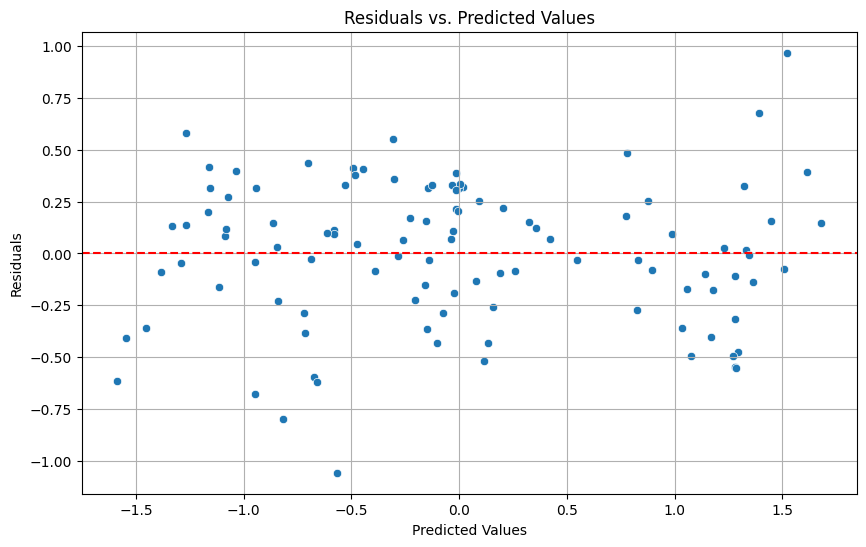

RunTest
Z-test statistic: -1.5333256503608763
P-value: 0.12519563764050898
Durbin-Watson Statistic: 1.61
{'Lagrange multiplier statistic': np.float64(3.8118054153033265), 'p-value': np.float64(0.2825159459140847), 'f-value': np.float64(1.268261805064926), 'f p-value': np.float64(0.289315285577514)}
Shapiro-Wilk Test: ShapiroResult(statistic=np.float64(0.9846958079508217), pvalue=np.float64(0.2646469416632771))
White Test: (np.float64(27.84673571476838), np.float64(0.0010117600079532624), np.float64(3.800632645875614), np.float64(0.00039194158530806523))
Kolmogorov: KstestResult(statistic=np.float64(0.2837994897625681), pvalue=np.float64(4.773547742270942e-08), statistic_location=np.float64(0.43723820924697976), statistic_sign=np.int8(1))


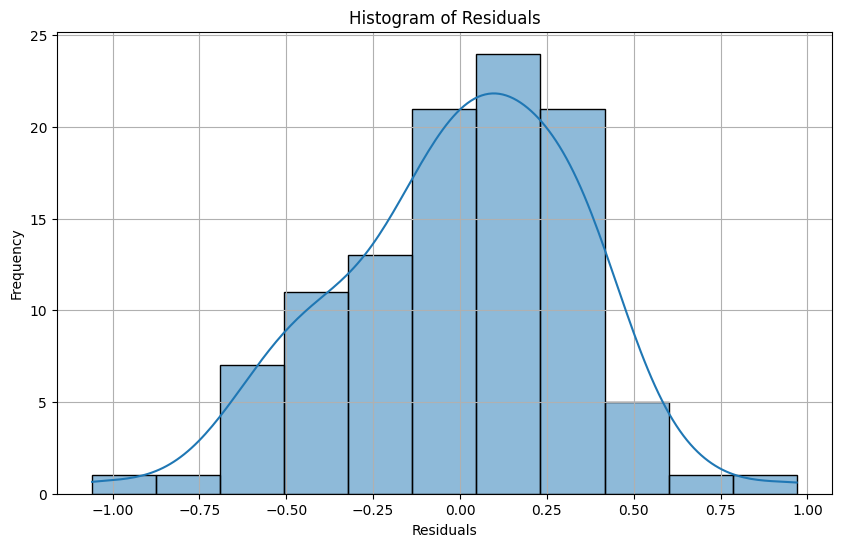

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.865
Method:                 Least Squares   F-statistic:                     226.2
Date:                Mon, 20 Oct 2025   Prob (F-statistic):           6.43e-45
Time:                        07:30:51   Log-Likelihood:                -37.136
No. Observations:                 106   AIC:                             82.27
Df Residuals:                     102   BIC:                             92.93
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2595      0.037     -7.001      0.0

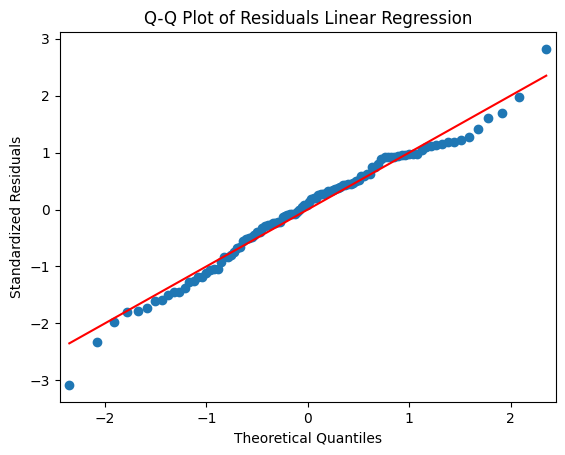

In [ ]:
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.diagnostic import het_white
from scipy.stats import kstest

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_predlinear.flatten(), y=residualslinear.flatten())
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

z_stat, p_value = runstest_1samp(residualslinear.flatten(), correction=False)
print('RunTest')
print("Z-test statistic:", z_stat)
print("P-value:", p_value)

dw = durbin_watson(residualslinear.flatten())
print(f'Durbin-Watson Statistic: {dw:.2f}')

X_const = sm.add_constant(X_train_drop)
bp_test = het_breuschpagan(residualslinear.flatten(), X_const)
labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
print(dict(zip(labels, bp_test)))

shapiro = stats.shapiro(residualslinear.flatten())
print(f'Shapiro-Wilk Test: {shapiro}')

white_test = het_white(residualslinear.flatten(), X_const)
print(f'White Test: {white_test}')

ks_test = kstest(residualslinear.flatten(), 'norm')
print(f'Kolmogorov: {ks_test}')

plt.figure(figsize=(10, 6))
sns.histplot(residualslinear, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

model_sm = sm.OLS(y_train_log, X_const).fit()
print(model_sm.summary())

sm.qqplot(residualslinear, line='s', fit=True)
plt.title('Q-Q Plot of Residuals Linear Regression')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Standardized Residuals')
plt.show()

In [ ]:
vif = calculate_vif(X_train_drop)
print(vif)

       Column       VIF
0  EX_AVG_USD  1.246769
1     IMI_IDX  1.071599
2      policy  1.191957


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np  # สำหรับ sqrt ถ้าต้องการ manual

# Train metrics
print("Train R2:", r2_score(y_train_log, y_predlinear))
print("Train MAE:", mean_absolute_error(y_train_log, y_predlinear))
print("Train MSE:", mean_squared_error(y_train_log, y_predlinear))
print("Train RMSE:",np.sqrt(mean_squared_error(y_train_log, y_predlinear)))

# Test metrics (สมมติมี y_test_log)
print("Test R2:", r2_score(y_test_log, y_pred))
print("Test MAE:", mean_absolute_error(y_test_log, y_pred))
print("Test MSE:", mean_squared_error(y_test_log, y_pred))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test_log, y_pred)))

# ถ้าต้องการบน original scale (inverse log ถ้า y_log = np.log(y))
y_pred_original = np.exp(y_pred)  # หรือ scaler.inverse ถ้าใช้
y_test_original = np.exp(y_test_log)
# แล้วคำนวณ metrics เหมือนด้านบน

Train R2: 0.8693104917571262
Train MAE: 0.2746073319851998
Train MSE: 0.11798484303021434
Train RMSE: 0.34348921821538203
Test R2: 0.7757879960570309
Test MAE: 0.30740571433476765
Test MSE: 0.15572910809628548
Test RMSE: 0.3946252755416022


In [ ]:
y_pred

array([ 1.02181556, -0.85183945, -1.18668343, -0.07554087,  0.97098782,
        1.25106031, -0.3393184 ,  1.20570857, -0.80255994, -0.53504189,
        0.04811514, -0.09075498])

In [ ]:
y_pred_original.flatten()

array([2.77823425, 0.42662945, 0.30523191, 0.92724183, 2.64055156,
       3.49404575, 0.71225563, 3.33912425, 0.44818018, 0.58564476,
       1.04929146, 0.91324145])

In [ ]:
y_train

,CPI_IDX
0,90.16
1,100.64
2,92.03
3,91.63
4,98.92
...,...
101,90.68
102,99.94
103,100.67
104,95.58


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# --- 1. Reverse Transform ค่าที่ทำนาย (Predictions) ---
# เราต้อง .reshape(-1, 1) เพราะ .inverse_transform() คาดหวัง input 2D
y_predlinear_original = quantile.inverse_transform(y_predlinear.reshape(-1, 1))
y_pred_original = quantile.inverse_transform(y_pred.reshape(-1, 1))


# --- 2. คำนวณ Metrics โดยเปรียบเทียบกับค่า "ดั้งเดิม" (y_train, y_test) ---

print("--- Train Metrics (Original Scale) ---")
# เปรียบเทียบ y_train (ดั้งเดิม) กับ y_predlinear_original (ที่แปลงกลับแล้ว)
print("Train R2:", r2_score(y_train, y_predlinear_original))
print("Train MAE:", mean_absolute_error(y_train, y_predlinear_original))
print("Train MSE:", mean_squared_error(y_train, y_predlinear_original))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_predlinear_original)))

print("\n--- Test Metrics (Original Scale) ---")
# เปรียบเทียบ y_test (ดั้งเดิม) กับ y_pred_original (ที่แปลงกลับแล้ว)
print("Test R2:", r2_score(y_test, y_pred_original))
print("Test MAE:", mean_absolute_error(y_test, y_pred_original))
print("Test MSE:", mean_squared_error(y_test, y_pred_original))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_original)))

--- Train Metrics (Original Scale) ---
Train R2: 0.9688369964441701
Train MAE: 0.4664778765422922
Train MSE: 0.45164208150712787
Train RMSE: 0.6720432140176165

--- Test Metrics (Original Scale) ---
Test R2: 0.9478745135661263
Test MAE: 0.588221833762694
Test MSE: 0.7416006979448787
Test RMSE: 0.86116241089871


In [ ]:
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_predict

loo = LeaveOneOut()
y_predloo = cross_val_predict(
    estimator=linear_model,
    X=X_train_drop,
    y=y_train_log,
    cv=loo,
)

r2lnloo = r2_score(y_train_log,y_predloo)
mselnloo = mean_squared_error(y_train_log, y_predloo)
maelnloo = mean_absolute_error(y_train_log, y_predloo)
rmselnloo = np.sqrt(mselnloo)

print(f'R-squared Score (LN): {r2lnloo:.3f}')
print(f'Mean Squared Error (LN): {mselnloo:.3f}')
print(f'Mean Absolute Error (LN): {maelnloo:.3f}')
print(f'Root Mean Squared Error (LN): {rmselnloo:.3f}')

R-squared Score (LN): 0.858
Mean Squared Error (LN): 0.128
Mean Absolute Error (LN): 0.286
Root Mean Squared Error (LN): 0.358


In [ ]:
# @title
# from sklearn.inspection import permutation_importance
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# # อัปเดต feature names เหลือ x1, x3, x4
# feature_names = X_train_drop.columns

# # สมมติว่าได้ผลลัพธ์จาก permutation_importance (ใช้ค่า example เพราะไม่มี data จริง)
# perm_importance = permutation_importance(linear_model, X_train_drop, y_train_log, n_repeats=10, random_state=1234, scoring='r2')

# # สร้าง DataFrame จากผลลัพธ์
# perm_importance_df = pd.DataFrame({
#     'Feature': feature_names,
#     'Importance': perm_importance['importances_mean']
# })

# # คำนวณ Normalized Importance
# perm_importance_df['Normalized_Importance'] = perm_importance_df['Importance'] / np.abs(perm_importance_df['Importance']).sum()

# # เรียงลำดับตาม Importance
# perm_importance_df = perm_importance_df.sort_values(by='Importance', ascending=True)

# # แสดงผลลัพธ์ในตาราง
# print(perm_importance_df)

# # สร้างกราฟ
# plt.figure(figsize=(10, 8))
# bars = plt.barh(perm_importance_df['Feature'], perm_importance_df['Normalized_Importance'], color='red')

# # เพิ่ม percentage labels
# for bar, importance in zip(bars, perm_importance_df['Normalized_Importance']):
#     width = bar.get_width()
#     plt.text(width, bar.get_y() + bar.get_height()/2, f'{importance*100:.1f}%',
#              ha='left' if width >= 0 else 'right',
#              va='center')

# plt.xlabel('Normalized Permutation Importance')
# plt.title('Feature Importance (Multiple Linear Regression - Normalized Permutation Importance)')
# plt.axvline(x=0, color='grey', linestyle='--')
# plt.show()

# # แสดงผลลัพธ์ดิบจาก permutation_importance
# print(perm_importance)

  Feature  Importance  Normalized_Importance
2      x4    0.078500               0.042071
0      x3    0.080374               0.043075
1      x1    1.707048               0.914855


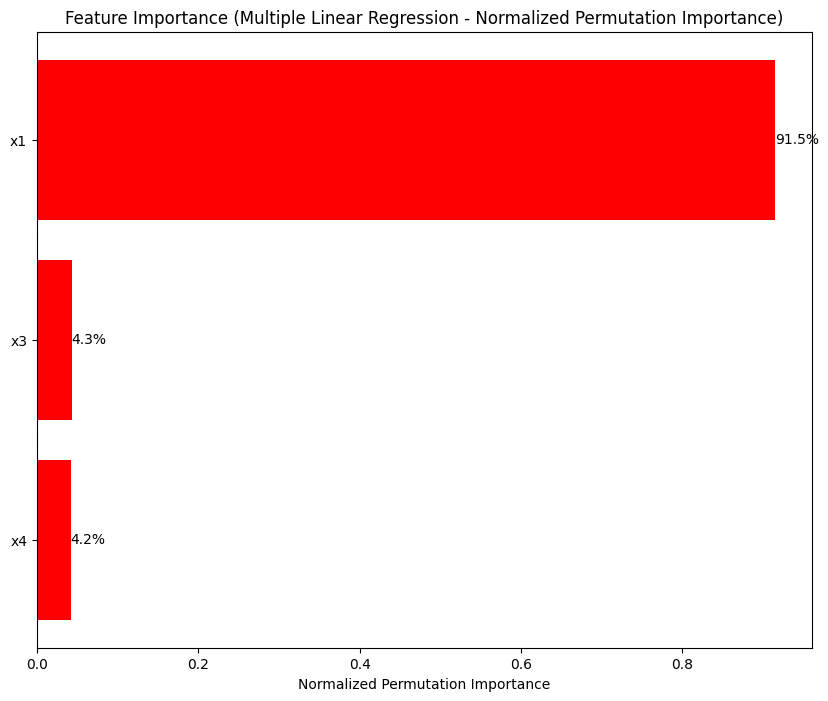

{'importances_mean': array([0.08037429, 1.70704803, 0.07850046]), 'importances_std': array([0.01159883, 0.09739401, 0.0127778 ]), 'importances': array([[0.07749573, 0.08286876, 0.08013533, 0.07267806, 0.08159601,
        0.06157856, 0.09545942, 0.10459927, 0.07615016, 0.07118162],
       [1.77475968, 1.67702829, 1.77739646, 1.66933214, 1.5539156 ,
        1.7496899 , 1.52085012, 1.71937885, 1.81268578, 1.81544353],
       [0.08039377, 0.0738718 , 0.09194335, 0.0810285 , 0.06992209,
        0.09436275, 0.05930538, 0.09817285, 0.06027149, 0.07573266]])}


In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# อัปเดต feature names เหลือ x1, x3, x4
feature_names = feature_names = ['x3','x1','x4']

# สมมติว่าได้ผลลัพธ์จาก permutation_importance (ใช้ค่า example เพราะไม่มี data จริง)
perm_importance = permutation_importance(linear_model, X_train_drop, y_train_log, n_repeats=10, random_state=1234, scoring='r2')

# สร้าง DataFrame จากผลลัพธ์
perm_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_importance['importances_mean']
})

# คำนวณ Normalized Importance
perm_importance_df['Normalized_Importance'] = perm_importance_df['Importance'] / np.abs(perm_importance_df['Importance']).sum()

# เรียงลำดับตาม Importance
perm_importance_df = perm_importance_df.sort_values(by='Importance', ascending=True)

# แสดงผลลัพธ์ในตาราง
print(perm_importance_df)

# สร้างกราฟ
plt.figure(figsize=(10, 8))
bars = plt.barh(perm_importance_df['Feature'], perm_importance_df['Normalized_Importance'], color='red')

# เพิ่ม percentage labels
for bar, importance in zip(bars, perm_importance_df['Normalized_Importance']):
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, f'{importance*100:.1f}%',
             ha='left' if width >= 0 else 'right',
             va='center')

plt.xlabel('Normalized Permutation Importance')
plt.title('Feature Importance (Multiple Linear Regression - Normalized Permutation Importance)')
plt.axvline(x=0, color='grey', linestyle='--')
plt.show()

# แสดงผลลัพธ์ดิบจาก permutation_importance
print(perm_importance)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

rf_model = RandomForestRegressor(random_state=69, n_estimators=200, min_samples_leaf=1, min_samples_split=2, max_depth = None)

rf_model.fit(X_train, y_train_log)

y_pred_rf = rf_model.predict(X_test)

r2ln = r2_score(y_test_log, y_pred_rf)
mseln = mean_squared_error(y_test_log, y_pred_rf)
maeln = mean_absolute_error(y_test_log, y_pred_rf)
rmseln = np.sqrt(mseln)

print(f'R-squared Score (RF): {r2ln:.3f}')
print(f'Mean Squared Error (RF): {mseln:.3f}')
print(f'Mean Absolute Error (RF): {maeln:.3f}')
print(f'Root Mean Squared Error (RF): {rmseln:.3f}')

R-squared Score (RF): 0.873
Mean Squared Error (RF): 0.088
Mean Absolute Error (RF): 0.248
Root Mean Squared Error (RF): 0.297


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

y_pred_rf_original = quantile.inverse_transform(y_pred_rf.reshape(-1, 1))

print("\n--- Test Metrics (Original Scale) ---")
# เปรียบเทียบ y_test (ดั้งเดิม) กับ y_pred_original (ที่แปลงกลับแล้ว)
print("Test R2:", r2_score(y_test, y_pred_rf_original))
print("Test MAE:", mean_absolute_error(y_test, y_pred_rf_original))
print("Test MSE:", mean_squared_error(y_test, y_pred_rf_original))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf_original)))


--- Test Metrics (Original Scale) ---
Test R2: 0.9672536165036055
Test MAE: 0.4920781036116845
Test MSE: 0.4658899612745946
Test RMSE: 0.6825613241860358


In [ ]:
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_predict

loo = LeaveOneOut()
y_predloo = cross_val_predict(
    estimator=rf_model,
    X=X_train,
    y=y_train_log,
    cv=loo,
)

r2lnloo = r2_score(y_train_log,y_predloo)
mselnloo = mean_squared_error(y_train_log, y_predloo)
maelnloo = mean_absolute_error(y_train_log, y_predloo)
rmselnloo = np.sqrt(mselnloo)

print(f'R-squared Score (LN): {r2lnloo:.3f}')
print(f'Mean Squared Error (LN): {mselnloo:.3f}')
print(f'Mean Absolute Error (LN): {maelnloo:.3f}')
print(f'Root Mean Squared Error (LN): {rmselnloo:.3f}')

R-squared Score (LN): 0.921
Mean Squared Error (LN): 0.071
Mean Absolute Error (LN): 0.202
Root Mean Squared Error (LN): 0.267


In [ ]:
# @title
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
# from sklearn.model_selection import GridSearchCV
# import numpy as np

# # Define the RandomForestRegressor model
# rf_model = RandomForestRegressor(random_state=69)

# # Define the parameter grid for GridSearchCV
# param_grid = {
#     'n_estimators': [50, 100, 200],  # Number of trees
#     'max_depth': [None, 10, 20, 30],  # Maximum depth of trees
#     'min_samples_split': [2, 5, 10],  # Minimum samples to split a node
#     'min_samples_leaf': [1, 2, 4]  # Minimum samples at a leaf node
# }

# # Initialize GridSearchCV
# grid_search = GridSearchCV(
#     estimator=rf_model,
#     param_grid=param_grid,
#     scoring='neg_mean_squared_error',  # Use negative MSE as the scoring metric
#     cv=5,  # 5-fold cross-validation
#     n_jobs=-1,  # Use all available CPU cores
#     verbose=1
# )

# # Fit GridSearchCV to the training data
# grid_search.fit(X_train, y_train_log)

# # Get the best model from GridSearchCV
# best_rf_model = grid_search.best_estimator_

# # Predict on the test set using the best model
# y_pred_rf = best_rf_model.predict(X_test)

# # Calculate evaluation metrics
# r2ln = r2_score(y_test_log, y_pred_rf)
# mseln = mean_squared_error(y_test_log, y_pred_rf)
# maeln = mean_absolute_error(y_test_log, y_pred_rf)
# rmseln = np.sqrt(mseln)

# # Print the best parameters and evaluation metrics
# print("Best Parameters from GridSearchCV:")
# print(grid_search.best_params_)
# print(f'R-squared Score (LN): {r2ln:.3f}')
# print(f'Mean Squared Error (LN): {mseln:.3f}')
# print(f'Mean Absolute Error (LN): {maeln:.3f}')
# print(f'Root Mean Squared Error (LN): {rmseln:.3f}')

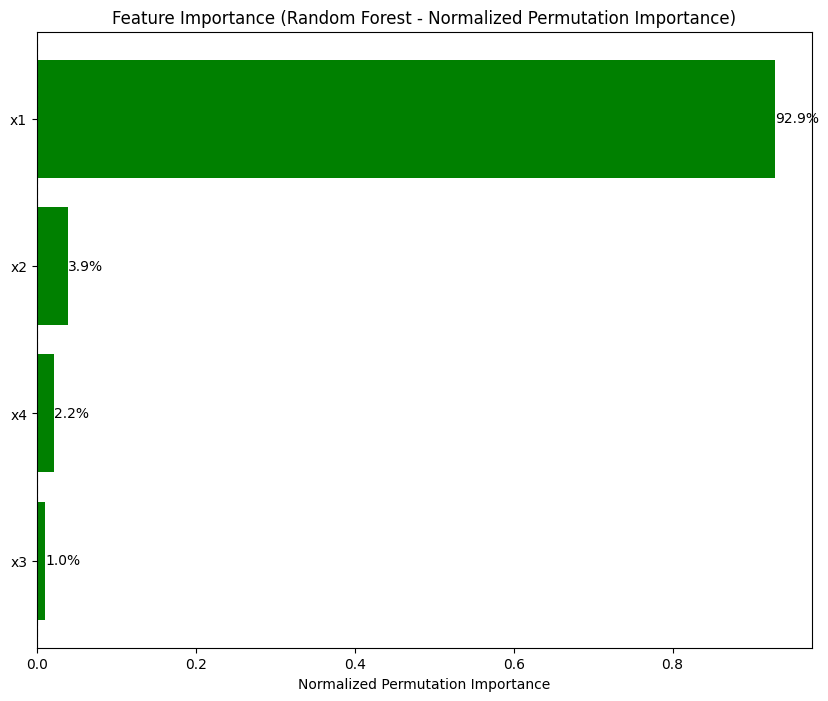

  Feature  Importance   Std_Dev  Normalized_Importance
0      x3    0.020205  0.002715               0.010316
2      x4    0.042202  0.010350               0.021547
3      x2    0.076941  0.011399               0.039284
1      x1    1.819219  0.073624               0.928852
{'importances_mean': array([0.0202054 , 1.8192189 , 0.04220207, 0.07694132]), 'importances_std': array([0.00271453, 0.07362398, 0.01035008, 0.01139911]), 'importances': array([[0.01981277, 0.023094  , 0.02265145, 0.01819351, 0.01903322,
        0.02490698, 0.01697317, 0.01573786, 0.02132725, 0.0203238 ],
       [1.85048695, 1.80322606, 1.9215216 , 1.84143259, 1.70975118,
        1.90697978, 1.67363402, 1.80422193, 1.84190401, 1.8390309 ],
       [0.05317852, 0.02598804, 0.04637397, 0.03422212, 0.04607188,
        0.04287957, 0.03951521, 0.06301609, 0.03000105, 0.0407742 ],
       [0.07655818, 0.052941  , 0.09520831, 0.07688937, 0.08684234,
        0.08278332, 0.07049711, 0.08776732, 0.06916647, 0.07075981]])}


In [ ]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Assuming rf_model (RandomForestRegressor) is already trained
# Assuming X_train_log and y_train_log are the training data used for rf_model

feature_names = ['x3','x1','x4','x2']  # Use columns from X_train_log

# Calculate permutation importance for the Random Forest model
perm_importance = permutation_importance(rf_model, X_train, y_train_log, n_repeats=10, random_state=1234, scoring='r2')

perm_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_importance['importances_mean'],
    'Std_Dev': perm_importance['importances_std']  # Add standard deviation
})

# Normalize importance values
perm_importance_df['Normalized_Importance'] = perm_importance_df['Importance'] / np.abs(perm_importance_df['Importance']).sum()

# Sort by Importance (mean) for plotting
perm_importance_df = perm_importance_df.sort_values(by='Importance', ascending=True)

# Plot horizontal bar chart without error bars
plt.figure(figsize=(10, 8))
bars = plt.barh(perm_importance_df['Feature'], perm_importance_df['Normalized_Importance'], color='green')

# Add percentage labels to the bars
for bar, importance in zip(bars, perm_importance_df['Normalized_Importance']):
    width = bar.get_width()
    # Position the text at the end of the bar (slightly offset)
    plt.text(width, bar.get_y() + bar.get_height()/2, f'{importance*100:.1f}%',
             ha='left' if width >= 0 else 'right',
             va='center')

plt.xlabel('Normalized Permutation Importance')
plt.title('Feature Importance (Random Forest - Normalized Permutation Importance)')
plt.axvline(x=0, color='grey', linestyle='--')
plt.show()

print(perm_importance_df)
print(perm_importance)

In [ ]:
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Initialize and train the SVR model
# Using default parameters for now, can be tuned later
svr_model = SVR(kernel='linear',C = 500,epsilon = 0.1, degree=2, gamma='scale')

# Fit the model on the training data
# Using X_train_log and y_train_log which have been processed (imputed, scaled, transformed)
svr_model.fit(X_train, y_train_log)

# Make predictions on the test data
y_pred_svr = svr_model.predict(X_test)

# Evaluate the model's performance
r2_svr = r2_score(y_test_log, y_pred_svr)
mse_svr = mean_squared_error(y_test_log, y_pred_svr)
mae_svr = mean_absolute_error(y_test_log, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)

print(f'R-squared Score (SVR): {r2_svr:.3f}')
print(f'Mean Squared Error (SVR): {mse_svr:.3f}')
print(f'Mean Absolute Error (SVR): {mae_svr:.3f}')
print(f'Root Mean Squared Error (SVR): {rmse_svr:.3f}')

R-squared Score (SVR): 0.808
Mean Squared Error (SVR): 0.133
Mean Absolute Error (SVR): 0.256
Root Mean Squared Error (SVR): 0.365


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

y_pred_svr_original = quantile.inverse_transform(y_pred_svr.reshape(-1, 1))

print("\n--- Test Metrics (Original Scale) ---")
# เปรียบเทียบ y_test (ดั้งเดิม) กับ y_pred_original (ที่แปลงกลับแล้ว)
print("Test R2:", r2_score(y_test, y_pred_svr_original))
print("Test MAE:", mean_absolute_error(y_test, y_pred_svr_original))
print("Test MSE:", mean_squared_error(y_test, y_pred_svr_original))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_svr_original)))


--- Test Metrics (Original Scale) ---
Test R2: 0.9592741344435145
Test MAE: 0.5007075710359826
Test MSE: 0.5794157980552098
Test RMSE: 0.7611936665890027


In [ ]:
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_predict

loo = LeaveOneOut()
y_predloo = cross_val_predict(
    estimator=svr_model,
    X=X_train,
    y=y_train_log,
    cv=loo,
)

r2lnloo = r2_score(y_train_log,y_predloo)
mselnloo = mean_squared_error(y_train_log, y_predloo)
maelnloo = mean_absolute_error(y_train_log, y_predloo)
rmselnloo = np.sqrt(mselnloo)

print(f'R-squared Score (LN): {r2lnloo:.3f}')
print(f'Mean Squared Error (LN): {mselnloo:.3f}')
print(f'Mean Absolute Error (LN): {maelnloo:.3f}')
print(f'Root Mean Squared Error (LN): {rmselnloo:.3f}')

R-squared Score (LN): 0.861
Mean Squared Error (LN): 0.126
Mean Absolute Error (LN): 0.266
Root Mean Squared Error (LN): 0.354


In [ ]:
# @title
# from sklearn.svm import SVR
# from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
# from sklearn.model_selection import GridSearchCV
# import numpy as np

# # Define the SVR model
# svr_model = SVR()

# # Define an extensive parameter grid for GridSearchCV
# param_grid = {
#     'kernel': ['linear'],  # Kernel types
#     'C': [0.01, 0.1, 1, 10, 50, 100, 500],  # Extensive range for regularization
#     'epsilon': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0],  # Extensive range for epsilon
#     'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1.0, 10.0],  # Extensive range for rbf/poly kernels
#     'degree': [2, 3, 4]  # Degrees for poly kernel
# }

# # Initialize GridSearchCV
# grid_search = GridSearchCV(
#     estimator=svr_model,
#     param_grid=param_grid,
#     scoring='neg_mean_squared_error',  # Optimize for lowest MSE
#     cv=5,  # 5-fold cross-validation
#     n_jobs=-1,  # Use all available CPU cores
#     verbose=2  # More detailed output for tracking progress
# )

# # Fit GridSearchCV to the training data
# grid_search.fit(X_train, y_train_log)

# # Get the best model from GridSearchCV
# best_svr_model = grid_search.best_estimator_

# # Predict on the test set using the best model
# y_pred_svr = best_svr_model.predict(X_test)

# # Calculate evaluation metrics
# r2_svr = r2_score(y_test_log, y_pred_svr)
# mse_svr = mean_squared_error(y_test_log, y_pred_svr)
# mae_svr = mean_absolute_error(y_test_log, y_pred_svr)
# rmse_svr = np.sqrt(mse_svr)

# # Print the best parameters and evaluation metrics
# print("Best Parameters from GridSearchCV:")
# print(grid_search.best_params_)
# print(f'R-squared Score (SVR): {r2_svr:.3f}')
# print(f'Mean Squared Error (SVR): {mse_svr:.3f}')
# print(f'Mean Absolute Error (SVR): {mae_svr:.3f}')
# print(f'Root Mean Squared Error (SVR): {rmse_svr:.3f}')

# # Optional: Print cross-validation results for top 5 parameter sets
# import pandas as pd
# results = pd.DataFrame(grid_search.cv_results_)
# top_results = results[['param_kernel', 'param_C', 'param_epsilon', 'param_gamma', 'param_degree', 'mean_test_score', 'std_test_score']].head()
# print("\nTop 5 Parameter Sets from GridSearchCV:")
# print(top_results)

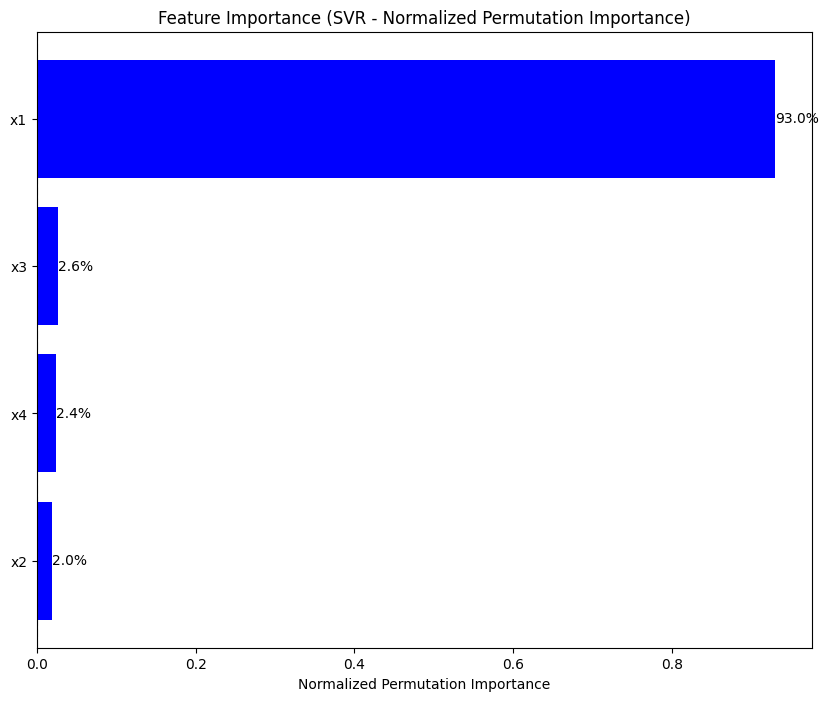

  Feature  Importance   Std_Dev  Normalized_Importance
3      x2    0.047177  0.017342               0.019570
2      x4    0.059023  0.009357               0.024484
0      x3    0.063731  0.012468               0.026437
1      x1    2.240723  0.125601               0.929508
{'importances_mean': array([0.06373082, 2.24072285, 0.05902334, 0.04717664]), 'importances_std': array([0.01246808, 0.12560062, 0.00935697, 0.01734246]), 'importances': array([[0.06023415, 0.06765403, 0.06091871, 0.05477296, 0.06926692,
        0.0456719 , 0.0782461 , 0.09052424, 0.05581165, 0.0542075 ],
       [2.32713444, 2.15986283, 2.31345636, 2.20685029, 2.06380869,
        2.27579359, 2.00128176, 2.27302517, 2.38933796, 2.39667745],
       [0.05941904, 0.05773948, 0.0673466 , 0.05669842, 0.04906323,
        0.0688805 , 0.04373526, 0.07627788, 0.05069321, 0.06037981],
       [0.04510621, 0.00865097, 0.05452726, 0.06826136, 0.06179016,
        0.02847829, 0.04428673, 0.06773827, 0.0429164 , 0.05001071]])}


In [ ]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Assuming svr_model is already trained
# Assuming X_train_log and y_train_log are the training data used for svr_model

feature_names = ['x3','x1','x4','x2']

# Refit the SVR model before calculating permutation importance
# Using the same parameters as the last successful SVR fit
svr_model.fit(X_train, y_train_log)

# Calculate permutation importance for the SVR model
perm_importance_svr = permutation_importance(svr_model, X_train, y_train_log, n_repeats=10, random_state=1234, scoring='r2')

perm_importance_df_svr = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_importance_svr['importances_mean'],
    'Std_Dev': perm_importance_svr['importances_std']  # Add standard deviation
})

# Normalize importance values
perm_importance_df_svr['Normalized_Importance'] = perm_importance_df_svr['Importance'] / np.abs(perm_importance_df_svr['Importance']).sum()

# Sort by Importance (mean) for plotting
perm_importance_df_svr = perm_importance_df_svr.sort_values(by='Importance', ascending=True)

# Plot horizontal bar chart without error bars
plt.figure(figsize=(10, 8))
bars = plt.barh(perm_importance_df_svr['Feature'], perm_importance_df_svr['Normalized_Importance'], color='blue')

# Add percentage labels to the bars
for bar, importance in zip(bars, perm_importance_df_svr['Normalized_Importance']):
    width = bar.get_width()
    # Position the text at the end of the bar (slightly offset)
    plt.text(width, bar.get_y() + bar.get_height()/2, f'{importance*100:.1f}%',
             ha='left' if width >= 0 else 'right',
             va='center')

plt.xlabel('Normalized Permutation Importance')
plt.title('Feature Importance (SVR - Normalized Permutation Importance)')
plt.axvline(x=0, color='grey', linestyle='--')
plt.show()

print(perm_importance_df_svr)
print(perm_importance_svr)